In [1]:
import zipfile
import pandas as pd

In [2]:
# Extract ZIP file
with zipfile.ZipFile("hotel_booking.csv.zip", "r") as zip_ref:
    zip_ref.extractall("hotel_data")

In [3]:
# Load CSV file
file_path = "hotel_data/hotel_booking.csv"

df = pd.read_csv(file_path)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 119390
Columns: 36


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [4]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
print(df.isnull().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [6]:
# Make a copy
hotel = df.copy()


# --------------------------------------------------
# 1. Remove unnecessary columns
# --------------------------------------------------

# Remove mostly missing columns
hotel.drop(columns=["agent", "company"], inplace=True)

# Remove personal/sensitive information
hotel.drop(
    columns=["name", "email", "phone-number", "credit_card"],
    inplace=True
)


# --------------------------------------------------
# 2. Handle missing values
# --------------------------------------------------

# Fill missing children values
hotel["children"] = hotel["children"].fillna(0)

# Fill missing country values
hotel["country"] = hotel["country"].fillna("Unknown")


# --------------------------------------------------
# 3. Check and remove duplicates
# --------------------------------------------------

print("Duplicate records before cleaning:", hotel.duplicated().sum())

hotel.drop_duplicates(inplace=True)

print("Duplicate records after cleaning:", hotel.duplicated().sum())


# --------------------------------------------------
# 4. Create proper arrival date
# --------------------------------------------------

hotel["arrival_date"] = pd.to_datetime(
    hotel["arrival_date_year"].astype(str) + "-" +
    hotel["arrival_date_month"] + "-" +
    hotel["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d"
)


# --------------------------------------------------
# 5. Create useful derived columns
# --------------------------------------------------

# Total nights stayed
hotel["total_nights"] = (
    hotel["stays_in_weekend_nights"] +
    hotel["stays_in_week_nights"]
)


# Total guests
hotel["total_guests"] = (
    hotel["adults"] +
    hotel["children"] +
    hotel["babies"]
)


# Total requests
hotel["total_extra_requests"] = (
    hotel["total_of_special_requests"] +
    hotel["required_car_parking_spaces"]
)


# --------------------------------------------------
# 6. Standardize column names
# --------------------------------------------------

hotel.columns = (
    hotel.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)


# --------------------------------------------------
# 7. Check cleaned data
# --------------------------------------------------

print("Original rows:", len(df))
print("Cleaned rows:", len(hotel))
print("Columns:", len(hotel.columns))

print("\nMissing values:")
print(hotel.isnull().sum()[hotel.isnull().sum() > 0])

hotel.head()

Duplicate records before cleaning: 32020
Duplicate records after cleaning: 0
Original rows: 119390
Cleaned rows: 87370
Columns: 34

Missing values:
Series([], dtype: int64)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_nights,total_guests,total_extra_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,0,2.0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,0,2.0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,1,1.0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,1,1.0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,2,2.0,1


In [7]:
from sqlalchemy import create_engine, text

In [14]:
import sys
print(sys.executable)

C:\Users\thami\anaconda3\python.exe


In [15]:
import sys
!{sys.executable} -m pip install pymysql

In [16]:
import pymysql
print("PyMySQL installed successfully!")

PyMySQL installed successfully!


In [17]:
import pandas as pd
from sqlalchemy import create_engine, text
import pymysql

username = "root"
password = "2129"
host = "localhost"
port = 3306

server_engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}"
)

print("Connection engine created successfully!")

Connection engine created successfully!


In [18]:
import sys
!{sys.executable} -m pip install pymysql

In [19]:
import pymysql

print("PyMySQL installed successfully!")

PyMySQL installed successfully!


In [20]:
import pandas as pd
from sqlalchemy import create_engine, text

username = "root"
password = "2129"
host = "localhost"
port = 3306

server_engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}"
)

print("Connection engine created successfully!")

Connection engine created successfully!


In [2]:
from sqlalchemy import create_engine, text

username = "root"
password = "9345003343"   # use the password you created during installation
host = "localhost"
port = 3306

server_engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}"
)

with server_engine.connect() as connection:
    print("MySQL connection successful!")

MySQL connection successful!


In [3]:
with server_engine.connect() as connection:
    connection.execute(
        text("CREATE DATABASE IF NOT EXISTS hotel_analytics")
    )
    connection.commit()

print("Database created successfully!")

Database created successfully!


In [4]:
db_engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/hotel_analytics"
)

print("Connected to hotel_analytics!")

Connected to hotel_analytics!


In [9]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\thami\DVT MINI PROJECT
['.ipynb_checkpoints', 'hotel_booking.csv.zip', 'hotel_data', 'Untitled.ipynb']


In [10]:
import pandas as pd

file_path = r"C:\Users\thami\DVT MINI PROJECT\hotel_booking.csv.zip"

df = pd.read_csv(file_path)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 119390
Columns: 36


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [11]:
hotel = df.copy()

hotel.drop(columns=["agent", "company"], inplace=True)

hotel["children"] = hotel["children"].fillna(0)
hotel["country"] = hotel["country"].fillna("Unknown")

hotel.drop_duplicates(inplace=True)

hotel["arrival_date"] = pd.to_datetime(
    hotel["arrival_date_year"].astype(str) + "-" +
    hotel["arrival_date_month"] + "-" +
    hotel["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d"
)

hotel["total_nights"] = (
    hotel["stays_in_weekend_nights"] +
    hotel["stays_in_week_nights"]
)

hotel["total_guests"] = (
    hotel["adults"] +
    hotel["children"] +
    hotel["babies"]
)

hotel["total_extra_requests"] = (
    hotel["total_of_special_requests"] +
    hotel["required_car_parking_spaces"]
)

hotel.columns = (
    hotel.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

print("Original rows:", len(df))
print("Cleaned rows:", len(hotel))
print("Columns:", len(hotel.columns))

hotel.head()

Original rows: 119390
Cleaned rows: 119390
Columns: 38


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reservation_status,reservation_status_date,name,email,phone-number,credit_card,arrival_date,total_nights,total_guests,total_extra_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322,2015-07-01,0,2.0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157,2015-07-01,0,2.0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734,2015-07-01,1,1.0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677,2015-07-01,1,1.0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498,2015-07-01,2,2.0,1


In [12]:
print(hotel.shape)

(119390, 38)


In [16]:
from sqlalchemy import create_engine, text

username = "root"
password = "9345003343"   # Your MySQL password
host = "localhost"
port = 3306                         # MySQL port

db_engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/hotel_analytics"
)

with db_engine.connect() as connection:
    print("Connected to hotel_analytics!")

Connected to hotel_analytics!


In [21]:
hotel.to_sql(
    "hotel_bookings",
    con=db_engine,
    if_exists="replace",
    index=False,
    chunksize=5000
)

print("Data loaded successfully!")

Data loaded successfully!


In [22]:
pd.read_sql(
    "SELECT COUNT(*) AS total_rows FROM hotel_bookings",
    db_engine
)

,total_rows
0,119390


In [23]:
pd.read_sql(
    "SELECT * FROM hotel_bookings LIMIT 5",
    db_engine
)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reservation_status,reservation_status_date,name,email,phone-number,credit_card,arrival_date,total_nights,total_guests,total_extra_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322,2015-07-01,0,2.0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157,2015-07-01,0,2.0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734,2015-07-01,1,1.0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677,2015-07-01,1,1.0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498,2015-07-01,2,2.0,1


In [24]:
pd.read_sql(
    "DESCRIBE hotel_bookings",
    db_engine
)

,Field,Type,Null,Key,Default,Extra
0,hotel,text,YES,,None,
1,is_canceled,bigint,YES,,None,
2,lead_time,bigint,YES,,None,
3,arrival_date_year,bigint,YES,,None,
4,arrival_date_month,text,YES,,None,
5,arrival_date_week_number,bigint,YES,,None,
6,arrival_date_day_of_month,bigint,YES,,None,
7,stays_in_weekend_nights,bigint,YES,,None,
8,stays_in_week_nights,bigint,YES,,None,
9,adults,bigint,YES,,None,


In [25]:
pd.read_sql(
    "SELECT COUNT(*) AS total_bookings FROM hotel_bookings",
    db_engine
)

,total_bookings
0,119390


In [26]:
pd.read_sql(
    """
    SELECT hotel, COUNT(*) AS total_bookings
    FROM hotel_bookings
    GROUP BY hotel
    """,
    db_engine
)

,hotel,total_bookings
0,Resort Hotel,40060
1,City Hotel,79330


In [27]:
pd.read_sql(
    """
    SELECT is_canceled, COUNT(*) AS total
    FROM hotel_bookings
    GROUP BY is_canceled
    """,
    db_engine
)

,is_canceled,total
0,0,75166
1,1,44224


In [28]:
pd.read_sql(
    """
    SELECT hotel, ROUND(AVG(adr), 2) AS average_price
    FROM hotel_bookings
    GROUP BY hotel
    """,
    db_engine
)

,hotel,average_price
0,Resort Hotel,94.95
1,City Hotel,105.30


In [29]:
pd.read_sql(
    """
    SELECT country, COUNT(*) AS total_bookings
    FROM hotel_bookings
    GROUP BY country
    ORDER BY total_bookings DESC
    LIMIT 10
    """,
    db_engine
)

,country,total_bookings
0,PRT,48590
1,GBR,12129
2,FRA,10415
3,ESP,8568
4,DEU,7287
5,ITA,3766
6,IRL,3375
7,BEL,2342
8,BRA,2224
9,NLD,2104


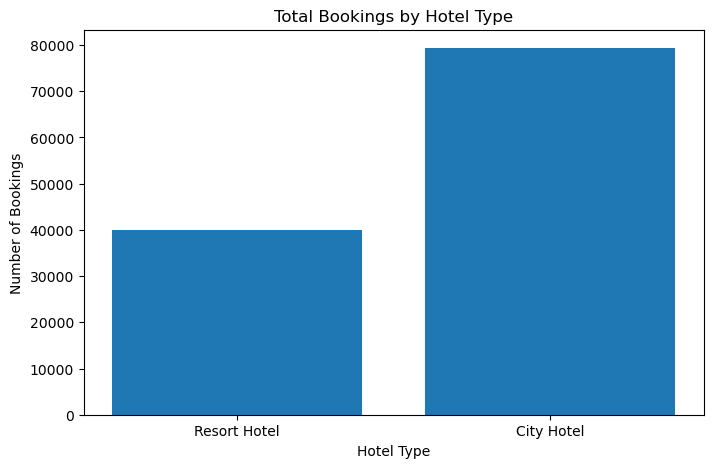

In [30]:
import matplotlib.pyplot as plt

query = """
SELECT hotel, COUNT(*) AS total_bookings
FROM hotel_bookings
GROUP BY hotel
"""

result = pd.read_sql(query, db_engine)

plt.figure(figsize=(8, 5))
plt.bar(result["hotel"], result["total_bookings"])
plt.title("Total Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.show()

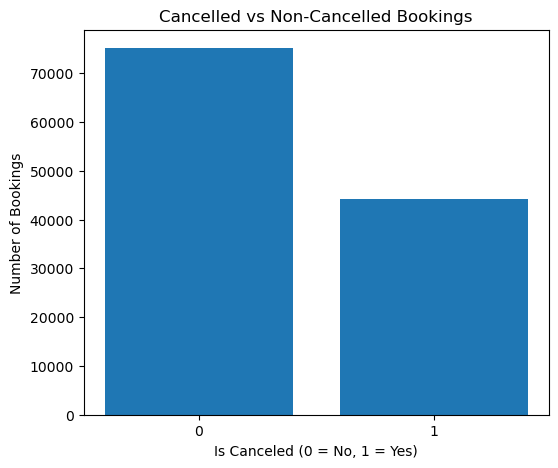

In [31]:
query = """
SELECT is_canceled, COUNT(*) AS total
FROM hotel_bookings
GROUP BY is_canceled
"""

result = pd.read_sql(query, db_engine)

plt.figure(figsize=(6, 5))
plt.bar(result["is_canceled"].astype(str), result["total"])
plt.title("Cancelled vs Non-Cancelled Bookings")
plt.xlabel("Is Canceled (0 = No, 1 = Yes)")
plt.ylabel("Number of Bookings")
plt.show()

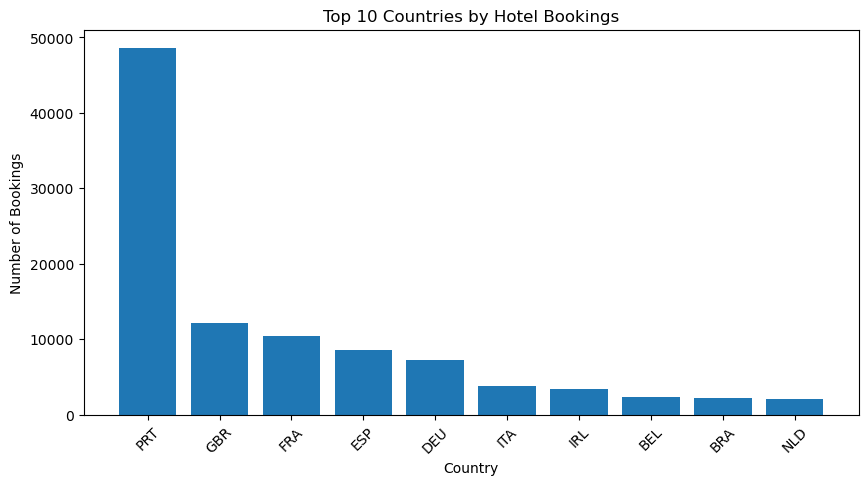

In [32]:
query = """
SELECT country, COUNT(*) AS total_bookings
FROM hotel_bookings
GROUP BY country
ORDER BY total_bookings DESC
LIMIT 10
"""

result = pd.read_sql(query, db_engine)

plt.figure(figsize=(10, 5))
plt.bar(result["country"], result["total_bookings"])
plt.title("Top 10 Countries by Hotel Bookings")
plt.xlabel("Country")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

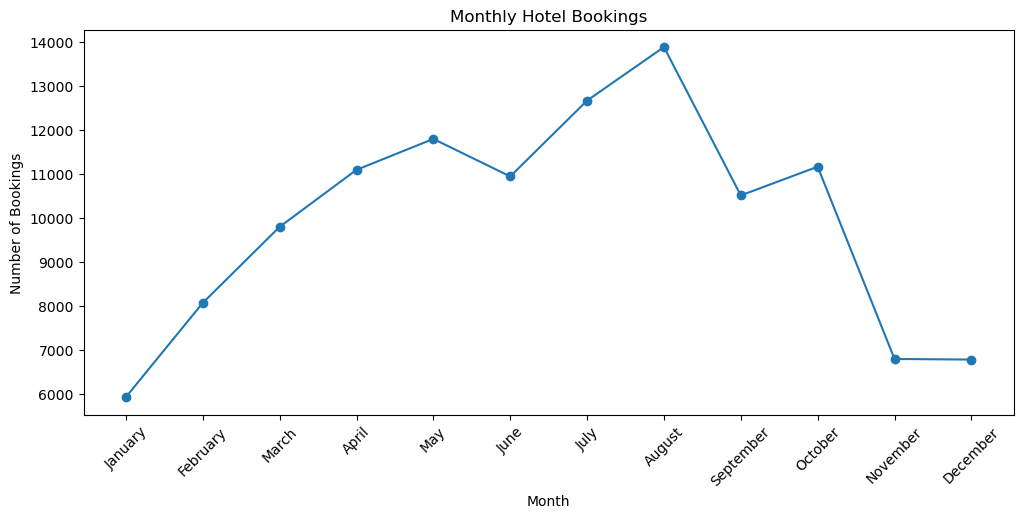

In [33]:
query = """
SELECT arrival_date_month, COUNT(*) AS total_bookings
FROM hotel_bookings
GROUP BY arrival_date_month
"""

monthly = pd.read_sql(query, db_engine)

# Correct month order
months = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly["arrival_date_month"] = pd.Categorical(
    monthly["arrival_date_month"],
    categories=months,
    ordered=True
)

monthly = monthly.sort_values("arrival_date_month")

plt.figure(figsize=(12, 5))
plt.plot(
    monthly["arrival_date_month"],
    monthly["total_bookings"],
    marker="o"
)

plt.title("Monthly Hotel Bookings")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

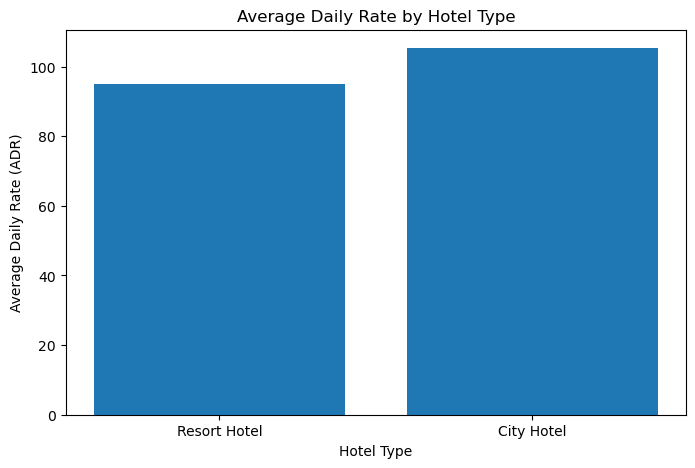

In [34]:
query = """
SELECT hotel, AVG(adr) AS average_price
FROM hotel_bookings
GROUP BY hotel
"""

price_data = pd.read_sql(query, db_engine)

plt.figure(figsize=(8, 5))
plt.bar(price_data["hotel"], price_data["average_price"])

plt.title("Average Daily Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average Daily Rate (ADR)")
plt.show()

In [35]:
# Total bookings
total_bookings = pd.read_sql(
    "SELECT COUNT(*) AS total FROM hotel_bookings",
    db_engine
).iloc[0, 0]

# Cancelled bookings
cancelled = pd.read_sql(
    "SELECT COUNT(*) AS cancelled FROM hotel_bookings WHERE is_canceled = 1",
    db_engine
).iloc[0, 0]

# Cancellation rate
cancellation_rate = (cancelled / total_bookings) * 100

print("===== HOTEL BOOKING ANALYTICS SUMMARY =====")
print("Total Bookings:", total_bookings)
print("Cancelled Bookings:", cancelled)
print("Cancellation Rate:", round(cancellation_rate, 2), "%")

===== HOTEL BOOKING ANALYTICS SUMMARY =====
Total Bookings: 119390
Cancelled Bookings: 44224
Cancellation Rate: 37.04 %


In [36]:
query = """
SELECT
    hotel,
    COUNT(*) AS total_bookings,
    ROUND(AVG(lead_time), 2) AS avg_lead_time,
    ROUND(AVG(adr), 2) AS avg_daily_rate
FROM hotel_bookings
GROUP BY hotel
"""

summary = pd.read_sql(query, db_engine)

summary

,hotel,total_bookings,avg_lead_time,avg_daily_rate
0,Resort Hotel,40060,92.68,94.95
1,City Hotel,79330,109.74,105.30
